# SpliceVarDB
Download and explore data from [SpliceVarDB](https://compbio.ccia.org.au/splicevardb/).

In [8]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.config as config
import src.splicevardb as sv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import variants

Import all variants data from SpliceVarDB.  

**NOTE**: This data was downloaded in bulk manually from the [SpliceVarDB](https://compbio.ccia.org.au/splicevardb/) website, 
and then stored in the folder `~/projects/data/splicevardb/`.  
There is an API that should in theory be able to download this data automatically, but it is currently not working.

In [2]:
# svdb = sv.get_variants() # API not working at the moment
svdb = pd.read_csv(os.path.join(config.DATA_DIR,"splicevardb","splicevardb.download.tsv.gz"), sep="\t")

In [3]:
print(svdb.shape)
svdb.head()

(50715, 9)


,variant_id,hg19,hg38,gene,hgvs,method,classification,location,doi
0,1,1-100573238-T-C,1-100107682-T-C,SASS6,NM_194292.3:c.1092A>G,MaPSy,Low-frequency,Exonic,"10.1371/journal.pgen.1009884,10.1371/journal.p..."
1,2,1-100576040-C-A,1-100110484-C-A,SASS6,NM_194292.3:c.670-1G>T,RNA-Seq,Splice-altering,Intronic,"10.1101/gr.231951.117,10.1016/j.molcel.2018.10..."
2,3,1-100671835-G-T,1-100206279-G-T,DBT,NM_001918.5:c.1232C>A,MaPSy,Low-frequency,Exonic,"10.1038/ng.3837,10.1038/ng.3837"
3,4,1-100672742-T-C,1-100207186-T-C,DBT,NM_001918.5:c.1018-550A>G,RT-PCR,Splice-altering,Intronic,10.1007/s100380050047
4,5,1-100701059-C-T,1-100235503-C-T,DBT,NM_001918.5:c.184G>A,MaPSy,Low-frequency,Exonic,"10.1038/ng.3837,10.1038/ng.3837"


## Characterize variants

### Variants per gene

count    8149.000000
mean        6.223463
std        14.502730
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       475.000000
dtype: float64


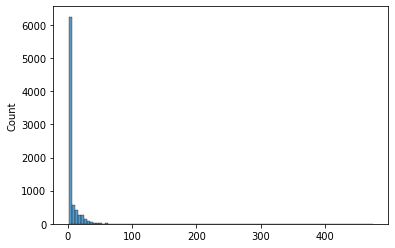

In [ ]:
variants_per_gene = svdb.groupby("gene").size()
print(variants_per_gene.describe())

sns.histplot(data=variants_per_gene, bins=100)
plt.show()

#### Variants per classification

count        4.000000
mean     12678.750000
std      10462.160018
min         83.000000
25%       8539.250000
50%      12515.500000
75%      16655.000000
max      25601.000000
Name: classification, dtype: float64


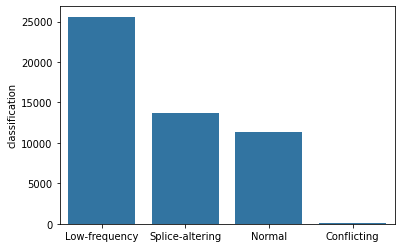

In [ ]:
variants_per_classification = svdb['classification'].value_counts()
print(variants_per_classification.describe())

sns.barplot(data=variants_per_classification)
plt.show()


### Variants per location

count        3.000000
mean     16905.000000
std      13988.333818
min        831.000000
25%      12198.500000
50%      23566.000000
75%      24942.000000
max      26318.000000
Name: location, dtype: float64


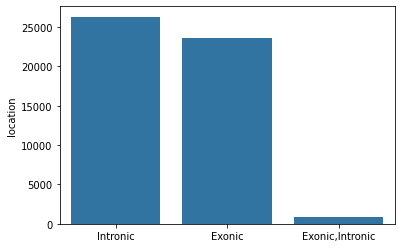

In [14]:
variants_per_location = svdb['location'].value_counts()
print(variants_per_location.describe())

sns.barplot(data=variants_per_location)
plt.show()


#### Variants per method

count       20.000000
mean      2535.750000
std       7048.040944
min          1.000000
25%          3.000000
50%         14.500000
75%        284.500000
max      28923.000000
Name: method, dtype: float64


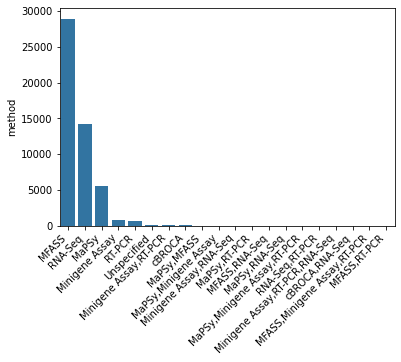

In [16]:
variants_per_method = svdb['method'].value_counts()
print(variants_per_method.describe())

sns.barplot(data=variants_per_method)
plt.xticks(rotation=45, ha='right')
plt.show()


### Variants per ClinVar status

In [17]:
# ????